Hybrid Probability-Based IRT for LLM evaluation.

Observation channels
--------------------
1. logprobs-available / deterministic probability channel:
   q[g,i] in [0,1] is deterministically obtained from model log-likelihoods.
   It is fitted by Bernoulli cross-entropy / KL projection:
   L_A = -sum(q log(mu) + (1-q) log(1-mu))

2. logprobs-unavailable / binary channel:
   r[g,i] ~ Binomial(R_b, mu[g,i])
   L_B = -sum(r log(mu) + (R_b-r) log(1-mu))

IRT model
---------
eta[g,i] = D * a[i] * (theta[g] - b[i])
mu[g,i] = sigmoid(eta[g,i])

Estimator
---------
Alternating optimization:
- theta updates with fixed a,b
- item parameter updates with fixed theta
- standardize theta to mean 0, sd 1 after each outer iteration

Notes
-----
- No repeated-measurement variance is used for the deterministic probability channel.
- The probability-channel information used below is the local/model-based curvature
  mu(1-mu), not an empirical sampling variance of q.
- Each model-condition is treated as a respondent.


In [1]:
from __future__ import annotations

import time
from dataclasses import dataclass
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
from scipy.optimize import minimize, minimize_scalar

In [2]:
D = 1.702

In [3]:
# 基礎的な関数・処理

EPS = 1e-12


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40.0, 40.0)))


def logit(p, eps=1e-8):
    p = np.clip(p, eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def clip_prob(mu, eps=EPS):
    return np.clip(mu, eps, 1.0 - eps)


def soft_bernoulli_nll(q, mu):
    """
    Deterministic probability q and IRT probability mu:
        -[q log(mu) + (1-q) log(1-mu)]

    This is cross-entropy. Up to the entropy of q (constant w.r.t. IRT parameters),
    it is KL(Ber(q) || Ber(mu)).
    """
    q = np.asarray(q, dtype=float)
    mu = clip_prob(np.asarray(mu, dtype=float))
    return -(q * np.log(mu) + (1.0 - q) * np.log1p(-mu))


def standardize_params(a, b, theta_p, theta_bin):
    parts = []
    if len(theta_p):
        parts.append(theta_p)
    if len(theta_bin):
        parts.append(theta_bin)
    base = np.concatenate(parts) if parts else np.array([0.0, 1.0])
    m = float(base.mean())
    s = float(base.std())
    if not np.isfinite(s) or s < 1e-8:
        s = 1.0
    return a * s, (b - m) / s, (theta_p - m) / s, (theta_bin - m) / s


def rmse(x, y):
    if len(x) == 0:
        return np.nan
    return float(np.sqrt(np.mean((np.asarray(x) - np.asarray(y)) ** 2)))


def corr(x, y):
    if len(x) < 2:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1])


def to_numpy_or_empty(x, n_items=None):
    """
    Convert DataFrame/array/None to numpy array.
    If x is None, return an empty array with shape (0, n_items).
    """
    if x is None:
        if n_items is None:
            return np.empty((0, 0))
        return np.empty((0, n_items))
    if isinstance(x, pd.DataFrame):
        return x.to_numpy(dtype=float)
    return np.asarray(x, dtype=float)


def infer_n_items(*arrays):
    for x in arrays:
        if x is None:
            continue
        if isinstance(x, pd.DataFrame):
            return x.shape[1]
        arr = np.asarray(x)
        if arr.ndim == 2:
            return arr.shape[1]
    raise ValueError("At least one non-empty 2D data matrix is required.")


def standardize_params_mixed(a, b, theta_full_p, theta_bin, theta_mix):
    parts = []
    if len(theta_full_p):
        parts.append(theta_full_p)
    if len(theta_bin):
        parts.append(theta_bin)
    if len(theta_mix):
        parts.append(theta_mix)

    if not parts:
        return a, b, theta_full_p, theta_bin, theta_mix

    theta_all = np.concatenate(parts)
    mean = theta_all.mean()
    sd = theta_all.std()

    if not np.isfinite(sd) or sd < 1e-8:
        sd = 1.0

    a_new = a * sd
    b_new = (b - mean) / sd

    theta_full_p_new = (theta_full_p - mean) / sd
    theta_bin_new = (theta_bin - mean) / sd
    theta_mix_new = (theta_mix - mean) / sd

    return a_new, b_new, theta_full_p_new, theta_bin_new, theta_mix_new


In [4]:
# 初期値の見積もり。NaNは初期値計算に含めない。
# ただし、全てNaNの項目があるなら最初から除外すること。
def initialize_params_mixed(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b,
    init_ab=None,
):
    """
    Initialize item parameters and abilities for:
      1. full deterministic-probability respondents
      2. full binary respondents
      3. item-wise mixed respondents
    """
    n_items = infer_n_items(p_full, r_bin, p_mix, r_mix, mask_mix)

    n_full_p = p_full.shape[0]
    n_bin = r_bin.shape[0]
    n_mix = p_mix.shape[0]

    if init_ab is None:
        item_means = []

        if n_full_p:
            item_means.append(np.nanmean(p_full, axis=0))

        if n_bin:
            item_means.append(np.nanmean(r_bin / R_b, axis=0))

        if n_mix:
            # 初期値用に各セルを[0,1]の正答確率相当に変換
            mix_prob_equiv = np.full_like(p_mix, np.nan, dtype=float)

            prob_available = (
                (mask_mix == 1)
                & np.isfinite(p_mix)
            )
            mix_prob_equiv[prob_available] = p_mix[prob_available]

            bin_available = (
                ~np.isfinite(mix_prob_equiv)
                & np.isfinite(r_mix)
            )
            mix_prob_equiv[bin_available] = r_mix[bin_available] / R_b

            item_means.append(np.nanmean(mix_prob_equiv, axis=0))

        p_item = np.nanmean(np.vstack(item_means), axis=0)
        p_item = np.clip(p_item, 1e-4, 1.0 - 1e-4)

        a = np.ones(n_items)
        b = -logit(p_item) / D
    else:
        a, b = [np.asarray(z, dtype=float).copy() for z in init_ab]

    # theta initialization
    if n_full_p:
        row_mean = np.nanmean(p_full, axis=1)
        theta_full_p = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_full_p = np.array([])

    if n_bin:
        row_mean = np.nanmean(r_bin / R_b, axis=1)
        theta_bin = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_bin = np.array([])

    if n_mix:
        mix_prob_equiv = np.full_like(p_mix, np.nan, dtype=float)

        prob_available = (
            (mask_mix == 1)
            & np.isfinite(p_mix)
        )
        mix_prob_equiv[prob_available] = p_mix[prob_available]

        bin_available = (
            ~np.isfinite(mix_prob_equiv)
            & np.isfinite(r_mix)
        )
        mix_prob_equiv[bin_available] = r_mix[bin_available] / R_b

        row_mean = np.nanmean(mix_prob_equiv, axis=1)
        theta_mix = logit(np.clip(row_mean, 1e-4, 1.0 - 1e-4)) / D
    else:
        theta_mix = np.array([])

    return standardize_params_mixed(a, b, theta_full_p, theta_bin, theta_mix)


In [5]:
# thetaの更新用

def probability_theta_objective(theta, p_g, a, b):
    mu = sigmoid(D * a * (theta - b))

    valid = np.isfinite(p_g)
    if not np.any(valid):
        return 0.0

    return float(np.sum(soft_bernoulli_nll(p_g[valid], mu[valid])))


def update_theta_full_probability(p_full, a, b, bounds=(-6.0, 6.0)):
    if p_full.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(p_full.shape[0])

    for g in range(p_full.shape[0]):
        res = minimize_scalar(
            lambda th: probability_theta_objective(th, p_full[g], a, b),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat


def binary_theta_objective(theta, r_g, R_b, a, b):
    mu = clip_prob(sigmoid(D * a * (theta - b)))

    valid = np.isfinite(r_g)
    if not np.any(valid):
        return 0.0

    return float(
        -np.sum(
            r_g[valid] * np.log(mu[valid])
            + (R_b - r_g[valid]) * np.log1p(-mu[valid])
        )
    )


def update_theta_binary(r_bin, R_b, a, b, bounds=(-6.0, 6.0)):
    if r_bin.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(r_bin.shape[0])

    for g in range(r_bin.shape[0]):
        res = minimize_scalar(
            lambda th: binary_theta_objective(th, r_bin[g], R_b, a, b),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat


def mixed_theta_objective(theta, p_g, r_g, mask_g, R_b, a, b):
    mu = clip_prob(sigmoid(D * a * (theta - b)))

    value = 0.0

    # deterministic probability / log-likelihood channel
    prob_idx = (
        (mask_g == 1)
        & np.isfinite(p_g)
    )
    if np.any(prob_idx):
        value += np.sum(
            soft_bernoulli_nll(p_g[prob_idx], mu[prob_idx])
        )

    # binary channel: rがあるセルは利用
    # mask==1 かつ rもfiniteなら、probability + binary の両方を使う
    bin_idx = np.isfinite(r_g)
    if np.any(bin_idx):
        value += -np.sum(
            r_g[bin_idx] * np.log(mu[bin_idx])
            + (R_b - r_g[bin_idx]) * np.log1p(-mu[bin_idx])
        )

    return float(value)


def update_theta_mixed(
    p_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    bounds=(-10.0, 10.0),
):
    if p_mix.shape[0] == 0:
        return np.array([])

    theta_hat = np.zeros(p_mix.shape[0])

    for g in range(p_mix.shape[0]):
        res = minimize_scalar(
            lambda th: mixed_theta_objective(
                th,
                p_mix[g],
                r_mix[g],
                mask_mix[g],
                R_b,
                a,
                b,
            ),
            bounds=bounds,
            method="bounded",
            options={"xatol": 1e-5},
        )
        theta_hat[g] = res.x

    return theta_hat


In [6]:
# 項目の更新用

def item_objective_and_grad_mixed(
    z,
    p_full_j,
    r_bin_j,
    p_mix_j,
    r_mix_j,
    mask_mix_j,
    R_b,
    theta_full_p,
    theta_bin,
    theta_mix,
    ridge=1e-4,
):
    alpha, bj = z
    aj = np.exp(alpha)

    value = 0.0
    grad_alpha = 0.0
    grad_b = 0.0

    # 1. full deterministic-probability group
    if len(theta_full_p):
        valid = np.isfinite(p_full_j)

        if np.any(valid):
            th = theta_full_p[valid]
            eta = D * aj * (th - bj)
            mu = clip_prob(sigmoid(eta))
            q = p_full_j[valid]

            value += np.sum(soft_bernoulli_nll(q, mu))

            # dL/deta = mu - q
            dL_deta = mu - q

            # alpha = log(a),  d eta / d alpha = eta
            grad_alpha += np.sum(dL_deta * eta)
            grad_b += np.sum(dL_deta * (-D * aj))

    # 2. full binary group
    if len(theta_bin):
        valid = np.isfinite(r_bin_j)

        if np.any(valid):
            th = theta_bin[valid]
            eta = D * aj * (th - bj)
            mu = clip_prob(sigmoid(eta))
            rj = r_bin_j[valid]

            value += -np.sum(
                rj * np.log(mu)
                + (R_b - rj) * np.log1p(-mu)
            )

            dL_deta = R_b * mu - rj

            # d eta / d alpha = eta
            grad_alpha += np.sum(dL_deta * eta)
            grad_b += np.sum(dL_deta * (-D * aj))

    # 3. mixed group
    if len(theta_mix):
        # probability part
        prob_idx = (
            (mask_mix_j == 1)
            & np.isfinite(p_mix_j)
        )

        if np.any(prob_idx):
            th = theta_mix[prob_idx]
            eta = D * aj * (th - bj)
            mu = clip_prob(sigmoid(eta))
            q = p_mix_j[prob_idx]

            value += np.sum(soft_bernoulli_nll(q, mu))

            dL_deta = mu - q
            grad_alpha += np.sum(dL_deta * eta)
            grad_b += np.sum(dL_deta * (-D * aj))

        # binary part
        bin_idx = np.isfinite(r_mix_j)

        if np.any(bin_idx):
            th = theta_mix[bin_idx]
            eta = D * aj * (th - bj)
            mu = clip_prob(sigmoid(eta))
            rj = r_mix_j[bin_idx]

            value += -np.sum(
                rj * np.log(mu)
                + (R_b - rj) * np.log1p(-mu)
            )

            dL_deta = R_b * mu - rj
            grad_alpha += np.sum(dL_deta * eta)
            grad_b += np.sum(dL_deta * (-D * aj))

    # ridge
    if ridge is not None and ridge > 0:
        value += ridge * (alpha ** 2 + bj ** 2)
        grad_alpha += 2.0 * ridge * alpha
        grad_b += 2.0 * ridge * bj

    return float(value), np.array([grad_alpha, grad_b])


def update_items_mixed(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
    item_maxiter=50,
    ridge=1e-4,
):
    n_items = len(a)
    new_a = a.copy()
    new_b = b.copy()

    for j in range(n_items):
        p_full_j = p_full[:, j] if p_full.shape[0] else np.array([])
        r_bin_j = r_bin[:, j] if r_bin.shape[0] else np.array([])

        p_mix_j = p_mix[:, j] if p_mix.shape[0] else np.array([])
        r_mix_j = r_mix[:, j] if r_mix.shape[0] else np.array([])
        mask_mix_j = mask_mix[:, j] if mask_mix.shape[0] else np.array([])

        z0 = np.array([np.log(max(a[j], 1e-4)), b[j]])

        res = minimize(
            lambda z: item_objective_and_grad_mixed(
                z,
                p_full_j,
                r_bin_j,
                p_mix_j,
                r_mix_j,
                mask_mix_j,
                R_b,
                theta_full_p,
                theta_bin,
                theta_mix,
                ridge=ridge,
            )[0],
            z0,
            jac=lambda z: item_objective_and_grad_mixed(
                z,
                p_full_j,
                r_bin_j,
                p_mix_j,
                r_mix_j,
                mask_mix_j,
                R_b,
                theta_full_p,
                theta_bin,
                theta_mix,
                ridge=ridge,
            )[1],
            method="L-BFGS-B",
            bounds=[(np.log(0.05), np.log(5.0)), (-5.0, 5.0)],
            options={
                "maxiter": item_maxiter,
                "ftol": 1e-7,
                "gtol": 1e-6,
                "maxls": 30,
            },
        )

        new_a[j] = np.exp(res.x[0])
        new_b[j] = res.x[1]

    return new_a, new_b


# 収束判定・ログ出力用
def objective_components_mixed(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
    ridge=1e-4,
):
    out = {
        "prob_full": 0.0,
        "bin_full": 0.0,
        "mix_prob": 0.0,
        "mix_bin": 0.0,
        "ridge": 0.0,
    }

    # full probability
    if len(theta_full_p):
        eta = D * a[None, :] * (theta_full_p[:, None] - b[None, :])
        mu = clip_prob(sigmoid(eta))
        valid = np.isfinite(p_full)

        if np.any(valid):
            ce = soft_bernoulli_nll(p_full, mu)
            out["prob_full"] = float(np.sum(ce[valid]))

    # full binary
    if len(theta_bin):
        eta = D * a[None, :] * (theta_bin[:, None] - b[None, :])
        mu = clip_prob(sigmoid(eta))
        valid = np.isfinite(r_bin)

        if np.any(valid):
            term = -(
                r_bin * np.log(mu)
                + (R_b - r_bin) * np.log1p(-mu)
            )
            out["bin_full"] = float(np.sum(term[valid]))

    # mixed
    if len(theta_mix):
        eta = D * a[None, :] * (theta_mix[:, None] - b[None, :])
        mu = clip_prob(sigmoid(eta))

        prob_idx = (
            (mask_mix == 1)
            & np.isfinite(p_mix)
        )
        bin_idx = np.isfinite(r_mix)

        if np.any(prob_idx):
            ce = soft_bernoulli_nll(p_mix, mu)
            out["mix_prob"] = float(np.sum(ce[prob_idx]))

        if np.any(bin_idx):
            term = -(
                r_mix * np.log(mu)
                + (R_b - r_mix) * np.log1p(-mu)
            )
            out["mix_bin"] = float(np.sum(term[bin_idx]))

    if ridge is not None and ridge > 0:
        alpha = np.log(np.clip(a, 1e-12, None))
        out["ridge"] = float(ridge * np.sum(alpha ** 2 + b ** 2))

    out["total"] = (
        out["prob_full"]
        + out["bin_full"]
        + out["mix_prob"]
        + out["mix_bin"]
        + out["ridge"]
    )

    return out


In [7]:
# 条件付き近似SEの計算。
# a,b推定ではtheta固定、theta推定ではa,b固定なので、同時推定誤差は無視している。
# deterministic probability channelについては、qの標本分散ではなく、
# cross-entropy目的関数の model-based/local curvature mu(1-mu) を用いる。
def compute_se_mixed(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b,
    a,
    b,
    theta_full_p,
    theta_bin,
    theta_mix,
):
    n_items = len(a)
    a_se = np.zeros(n_items)
    b_se = np.zeros(n_items)

    # item parameters: conditional model-based information for (a, b)
    for j in range(n_items):
        aj = a[j]
        bj = b[j]
        I = np.zeros((2, 2))

        # full probability group
        if len(theta_full_p):
            valid = np.isfinite(p_full[:, j])

            if np.any(valid):
                th = theta_full_p[valid]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[
                    D * (th - bj),                  # d eta / d a
                    -D * aj * np.ones_like(th),    # d eta / d b
                ]
                w = mu * (1.0 - mu)
                I += G.T @ (w[:, None] * G)

        # full binary group
        if len(theta_bin):
            valid = np.isfinite(r_bin[:, j])

            if np.any(valid):
                th = theta_bin[valid]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[
                    D * (th - bj),
                    -D * aj * np.ones_like(th),
                ]
                w = R_b * mu * (1.0 - mu)
                I += G.T @ (w[:, None] * G)

        # mixed group
        if len(theta_mix):
            # probability part
            prob_idx = (
                (mask_mix[:, j] == 1)
                & np.isfinite(p_mix[:, j])
            )

            if np.any(prob_idx):
                th = theta_mix[prob_idx]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[
                    D * (th - bj),
                    -D * aj * np.ones_like(th),
                ]
                w = mu * (1.0 - mu)
                I += G.T @ (w[:, None] * G)

            # binary part
            bin_idx = np.isfinite(r_mix[:, j])

            if np.any(bin_idx):
                th = theta_mix[bin_idx]
                eta = D * aj * (th - bj)
                mu = sigmoid(eta)

                G = np.c_[
                    D * (th - bj),
                    -D * aj * np.ones_like(th),
                ]
                w = R_b * mu * (1.0 - mu)
                I += G.T @ (w[:, None] * G)

        cov = np.linalg.pinv(I + 1e-8 * np.eye(2))
        a_se[j] = np.sqrt(max(cov[0, 0], 1e-12))
        b_se[j] = np.sqrt(max(cov[1, 1], 1e-12))

    # theta SEs: conditional curvature with a,b fixed
    theta_full_p_se = []
    for g, t in enumerate(theta_full_p):
        eta = D * a * (t - b)
        mu = sigmoid(eta)
        valid = np.isfinite(p_full[g])

        info = np.sum(
            (D ** 2)
            * (a[valid] ** 2)
            * mu[valid]
            * (1.0 - mu[valid])
        )
        theta_full_p_se.append(1.0 / np.sqrt(max(info, 1e-12)))
    theta_full_p_se = np.array(theta_full_p_se)

    theta_bin_se = []
    for g, t in enumerate(theta_bin):
        eta = D * a * (t - b)
        mu = sigmoid(eta)
        valid = np.isfinite(r_bin[g])

        info = np.sum(
            (D ** 2)
            * (a[valid] ** 2)
            * R_b
            * mu[valid]
            * (1.0 - mu[valid])
        )
        theta_bin_se.append(1.0 / np.sqrt(max(info, 1e-12)))
    theta_bin_se = np.array(theta_bin_se)

    theta_mix_se = []
    for g, t in enumerate(theta_mix):
        eta = D * a * (t - b)
        mu = sigmoid(eta)

        info = 0.0

        prob_idx = (
            (mask_mix[g] == 1)
            & np.isfinite(p_mix[g])
        )
        if np.any(prob_idx):
            info += np.sum(
                (D ** 2)
                * (a[prob_idx] ** 2)
                * mu[prob_idx]
                * (1.0 - mu[prob_idx])
            )

        bin_idx = np.isfinite(r_mix[g])
        if np.any(bin_idx):
            info += np.sum(
                (D ** 2)
                * (a[bin_idx] ** 2)
                * R_b
                * mu[bin_idx]
                * (1.0 - mu[bin_idx])
            )

        theta_mix_se.append(1.0 / np.sqrt(max(info, 1e-12)))
    theta_mix_se = np.array(theta_mix_se)

    return a_se, b_se, theta_full_p_se, theta_bin_se, theta_mix_se


In [19]:
def fit_hybrid_irt_with_itemwise_mixed(
    p_full=None,
    r_bin=None,
    p_mix=None,
    r_mix=None,
    mask_mix=None,
    R_b=1,
    init_ab=None,
    outer_iter=1000,
    item_maxiter=1000,
    tol_obj=1e-6,
    tol_param=1e-4,
    ridge=1e-4,
    verbose=True,
    print_every=1,
):
    """
    Fit IRT with:
      1. fully deterministic-probability-observed LLMs
      2. fully binary-observed LLMs
      3. item-wise mixed LLMs

    Data layout:
      rows = LLM/model-condition
      columns = items

    Probability channel:
      q is deterministic and is fitted by Bernoulli cross-entropy / KL projection.

    Binary channel:
      r ~ Binomial(R_b, mu).
    """

    n_items = infer_n_items(p_full, r_bin, p_mix, r_mix, mask_mix)

    p_full = to_numpy_or_empty(p_full, n_items)
    r_bin = to_numpy_or_empty(r_bin, n_items)

    p_mix = to_numpy_or_empty(p_mix, n_items)
    r_mix = to_numpy_or_empty(r_mix, n_items)

    if mask_mix is None:
        mask_mix = np.empty((0, n_items))
    elif isinstance(mask_mix, pd.DataFrame):
        mask_mix = mask_mix.to_numpy(dtype=float)
    else:
        mask_mix = np.asarray(mask_mix, dtype=float)

    # validation
    if p_mix.shape != r_mix.shape or p_mix.shape != mask_mix.shape:
        raise ValueError("p_mix, r_mix, and mask_mix must have the same shape.")

    if p_full.shape[1] != n_items or r_bin.shape[1] != n_items:
        raise ValueError("All data matrices must have the same number of items.")

    a, b, theta_full_p, theta_bin, theta_mix = initialize_params_mixed(
        p_full,
        r_bin,
        p_mix,
        r_mix,
        mask_mix,
        R_b,
        init_ab=init_ab,
    )

    history = []

    prev_comp = objective_components_mixed(
        p_full,
        r_bin,
        p_mix,
        r_mix,
        mask_mix,
        R_b,
        a,
        b,
        theta_full_p,
        theta_bin,
        theta_mix,
        ridge=ridge,
    )
    prev_obj = prev_comp["total"]

    prev_a = a.copy()
    prev_b = b.copy()
    prev_theta_full_p = theta_full_p.copy()
    prev_theta_bin = theta_bin.copy()
    prev_theta_mix = theta_mix.copy()

    converged = False
    stop_reason = "max_iter_reached"

    for it in range(1, outer_iter + 1):
        if len(theta_full_p):
            theta_full_p = update_theta_full_probability(
                p_full, a, b
            )

        if len(theta_bin):
            theta_bin = update_theta_binary(
                r_bin, R_b, a, b
            )

        if len(theta_mix):
            theta_mix = update_theta_mixed(
                p_mix,
                r_mix,
                mask_mix,
                R_b,
                a,
                b,
            )

        a, b, theta_full_p, theta_bin, theta_mix = standardize_params_mixed(
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
        )
        
        a, b = update_items_mixed(
            p_full,
            r_bin,
            p_mix,
            r_mix,
            mask_mix,
            R_b,
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
            item_maxiter=item_maxiter,
            ridge=ridge,
        )

        comp = objective_components_mixed(
            p_full,
            r_bin,
            p_mix,
            r_mix,
            mask_mix,
            R_b,
            a,
            b,
            theta_full_p,
            theta_bin,
            theta_mix,
            ridge=ridge,
        )

        obj = comp["total"]
        abs_obj_change = abs(prev_obj - obj)
        rel_obj_change = abs_obj_change / (abs(prev_obj) + 1e-12)

        max_delta_a = np.max(np.abs(a - prev_a)) if len(a) else 0.0
        max_delta_b = np.max(np.abs(b - prev_b)) if len(b) else 0.0
        max_delta_theta_full_p = (
            np.max(np.abs(theta_full_p - prev_theta_full_p))
            if len(theta_full_p)
            else 0.0
        )
        max_delta_theta_bin = (
            np.max(np.abs(theta_bin - prev_theta_bin))
            if len(theta_bin)
            else 0.0
        )
        max_delta_theta_mix = (
            np.max(np.abs(theta_mix - prev_theta_mix))
            if len(theta_mix)
            else 0.0
        )

        max_param_change = max(
            max_delta_a,
            max_delta_b,
            max_delta_theta_full_p,
            max_delta_theta_bin,
            max_delta_theta_mix,
        )

        mu_old = sigmoid(
        D * prev_a[None, :]
        * (prev_theta_full_p[:, None] - prev_b[None, :])
        )

        mu_new = sigmoid(
        D * a[None, :]
        * (theta_full_p[:, None] - b[None, :])
        )

        max_mu_change = np.max(
        np.abs(mu_new - mu_old)
        )
        
        meets_obj = rel_obj_change < tol_obj
        #meets_param = max_param_change < tol_param
        meets_mu = max_mu_change < tol_param
        #converged_now = meets_obj and meets_param
        converged_now = meets_obj and meets_mu


        row = {
            "iteration": it,
            "objective": obj,
            "objective_prob_full": comp["prob_full"],
            "objective_bin_full": comp["bin_full"],
            "objective_mix_prob": comp["mix_prob"],
            "objective_mix_bin": comp["mix_bin"],
            "objective_ridge": comp["ridge"],
            "relative_objective_change": rel_obj_change,
            "max_parameter_change": max_param_change,
            "max_delta_a": max_delta_a,
            "max_delta_b": max_delta_b,
            "max_delta_theta_full_p": max_delta_theta_full_p,
            "max_delta_theta_bin": max_delta_theta_bin,
            "max_delta_theta_mix": max_delta_theta_mix,
            "meets_obj_tol": meets_obj,
            #"meets_param_tol": meets_param,
            "meets_mu_tol": meets_mu,
            "converged": converged_now,
        }
        history.append(row)

        if verbose and (it == 1 or it % print_every == 0 or converged_now):
            print(
                f"[iter {it:03d}] "
                f"obj={obj:.6f} | "
                f"rel_dL={rel_obj_change:.3e} | "
                #f"max_dparam={max_param_change:.3e} | "
                f"max_dmu={max_mu_change:.3e} | "
                f"converged={converged_now}"
            )

        if converged_now:
            converged = True
            stop_reason = "converged"
            break

        prev_obj = obj
        prev_a = a.copy()
        prev_b = b.copy()
        prev_theta_full_p = theta_full_p.copy()
        prev_theta_bin = theta_bin.copy()
        prev_theta_mix = theta_mix.copy()

    a_se, b_se, theta_full_p_se, theta_bin_se, theta_mix_se = compute_se_mixed(
        p_full,
        r_bin,
        p_mix,
        r_mix,
        mask_mix,
        R_b,
        a,
        b,
        theta_full_p,
        theta_bin,
        theta_mix,
    )

    history_df = pd.DataFrame(history)

    return {
        "a": a,
        "b": b,
        "theta_full_probability": theta_full_p,
        "theta_binary": theta_bin,
        "theta_mixed": theta_mix,
        "a_se": a_se,
        "b_se": b_se,
        "theta_full_probability_se": theta_full_p_se,
        "theta_binary_se": theta_bin_se,
        "theta_mixed_se": theta_mix_se,
        "history": history_df,
        "converged": converged,
        "stop_reason": stop_reason,
        "n_iterations": len(history_df),
        "final_objective": (
            history_df["objective"].iloc[-1]
            if len(history_df)
            else np.nan
        ),
        "final_relative_objective_change": (
            history_df["relative_objective_change"].iloc[-1]
            if len(history_df)
            else np.nan
        ),
        "final_max_parameter_change": (
            history_df["max_parameter_change"].iloc[-1]
            if len(history_df)
            else np.nan
        ),
    }


実データでの検証

In [8]:
from pathlib import Path


def read_llm_table(path, name_col="model"):
    path = Path(path)

    try:
        df = pd.read_excel(path)
    except Exception:
        df = pd.read_csv(path, encoding="utf-8-sig")

    df.columns = df.columns.astype(str).str.strip()

    if name_col not in df.columns:
        raise ValueError(
            f"{path.name} に {name_col} 列がありません。"
        )

    df[name_col] = df[name_col].astype(str).str.strip()

    item_cols = [
        c for c in df.columns
        if c != name_col
    ]

    df[item_cols] = df[item_cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    return df


def split_llm_observation_tables_safe(
    probabilities_path,
    times_path=None,
    name_col="model",
    sort_models=True,
    keep_complete_prob_only_as_full=True,
):
    """
    実データ用の仕分け関数。

    方針
    ----
    1. probability と binary の両方にあるモデル
       -> p_mix, r_mix

    2. probability のみにあるモデル
       - 全項目観測あり -> p_full
       - 一部欠測あり   -> p_mix
                          r_mix は全NaN

    3. binary のみにあるモデル
       -> r_bin

    4. times_path=None の場合
       -> probability データだけで処理
       -> r_bin は0行
       -> r_mix は必要に応じて全NaN

    deterministic probability channel では
    SD/分散ファイルを使用しない。
    """

    # =========================================================
    # probability data
    # =========================================================
    prob_df = read_llm_table(
        probabilities_path,
        name_col=name_col
    )

    prob_item_cols = [
        c for c in prob_df.columns
        if c != name_col
    ]

    item_cols = prob_item_cols

    prob = (
        prob_df
        .set_index(name_col)[item_cols]
        .copy()
    )

    # =========================================================
    # binary data
    # =========================================================
    if times_path is not None:

        times_df = read_llm_table(
            times_path,
            name_col=name_col
        )

        times_item_cols = [
            c for c in times_df.columns
            if c != name_col
        ]

        if prob_item_cols != times_item_cols:
            raise ValueError(
                "probabilities と times の問題列が"
                "一致していません。"
            )

        times = (
            times_df
            .set_index(name_col)[item_cols]
            .copy()
        )

    else:
        # binaryデータなし
        times = pd.DataFrame(
            index=pd.Index([], name=name_col),
            columns=item_cols,
            dtype=float,
        )

    # =========================================================
    # 全欠測モデル除外
    # =========================================================

    # probability
    valid_prob_row = prob.notna().any(axis=1)

    dropped_prob_all_nan = (
        prob.index[~valid_prob_row].tolist()
    )

    prob = prob.loc[
        valid_prob_row
    ].copy()

    # binary
    if len(times) > 0:

        valid_times_row = (
            times.notna().any(axis=1)
        )

        dropped_times_all_nan = (
            times.index[
                ~valid_times_row
            ].tolist()
        )

        times = times.loc[
            valid_times_row
        ].copy()

    else:
        dropped_times_all_nan = []

    # =========================================================
    # model groups
    # =========================================================

    prob_names = set(prob.index)
    times_names = set(times.index)

    both_names = list(
        prob_names & times_names
    )

    prob_only_names = list(
        prob_names - times_names
    )

    times_only_names = list(
        times_names - prob_names
    )

    if sort_models:
        both_names = sorted(both_names)
        prob_only_names = sorted(
            prob_only_names
        )
        times_only_names = sorted(
            times_only_names
        )

    # =========================================================
    # probability-only:
    # complete / incomplete
    # =========================================================

    prob_only_complete = []
    prob_only_incomplete = []

    for name in prob_only_names:

        complete = (
            prob.loc[name]
            .notna()
            .all()
        )

        if complete:
            prob_only_complete.append(name)
        else:
            prob_only_incomplete.append(name)

    if not keep_complete_prob_only_as_full:

        prob_only_incomplete = (
            prob_only_names
        )

        prob_only_complete = []

    # =========================================================
    # full probability
    # =========================================================

    p_full = prob.loc[
        prob_only_complete
    ].copy()

    # =========================================================
    # binary only
    # =========================================================

    r_bin = times.loc[
        times_only_names
    ].copy()

    # =========================================================
    # mixed:
    # probability + binary
    # =========================================================

    # both
    p_mix_1 = prob.loc[
        both_names
    ].copy()

    r_mix_1 = times.loc[
        both_names
    ].copy()

    # probability only but incomplete
    p_mix_2 = prob.loc[
        prob_only_incomplete
    ].copy()

    r_mix_2 = pd.DataFrame(
        np.nan,
        index=prob_only_incomplete,
        columns=item_cols,
        dtype=float,
    )

    p_mix = pd.concat(
        [p_mix_1, p_mix_2],
        axis=0
    )

    r_mix = pd.concat(
        [r_mix_1, r_mix_2],
        axis=0
    )

    if sort_models:

        p_mix = p_mix.sort_index()
        r_mix = r_mix.sort_index()

        p_full = p_full.sort_index()
        r_bin = r_bin.sort_index()

    # =========================================================
    # mask
    # =========================================================

    mask_mix = (
        p_mix.notna()
        .astype(int)
    )

    # =========================================================
    # mixed行で何の観測もないものを除去
    # =========================================================

    has_prob_mix = (
        mask_mix.sum(axis=1) > 0
    )

    has_bin_mix = (
        r_mix.notna().any(axis=1)
    )

    valid_mix_row = (
        has_prob_mix
        | has_bin_mix
    )

    dropped_mix_no_observation = (
        p_mix.index[
            ~valid_mix_row
        ].tolist()
    )

    p_mix = p_mix.loc[
        valid_mix_row
    ].copy()

    r_mix = r_mix.loc[
        valid_mix_row
    ].copy()

    mask_mix = mask_mix.loc[
        valid_mix_row
    ].copy()

    # mask=0 の probability は NaN
    p_mix = p_mix.where(
        mask_mix == 1,
        np.nan
    )

    # =========================================================
    # validation
    # =========================================================

    if p_full.isna().any().any():
        raise ValueError(
            "p_full に NaN が残っています。"
        )

    # probability: [0, 1]
    for label, df in [
        ("p_full", p_full),
        ("p_mix", p_mix)
    ]:

        vals = df.to_numpy(
            dtype=float
        )

        finite = np.isfinite(vals)

        if finite.any():

            if (
                np.nanmin(vals[finite]) < 0
                or
                np.nanmax(vals[finite]) > 1
            ):
                raise ValueError(
                    f"{label} に "
                    "[0,1] 外の値があります。"
                )

    # binary/count
    for label, df in [
        ("r_bin", r_bin),
        ("r_mix", r_mix)
    ]:

        vals = df.to_numpy(
            dtype=float
        )

        finite = np.isfinite(vals)

        if finite.any():

            if np.nanmin(vals[finite]) < 0:

                raise ValueError(
                    f"{label} に"
                    "負の値があります。"
                )

    return {
        "p_full": p_full,
        "r_bin": r_bin,
        "p_mix": p_mix,
        "r_mix": r_mix,
        "mask_mix": mask_mix,

        "groups": {
            "both_names":
                both_names,

            "prob_only_complete":
                prob_only_complete,

            "prob_only_incomplete":
                prob_only_incomplete,

            "times_only_names":
                times_only_names,

            "dropped_prob_all_nan":
                dropped_prob_all_nan,

            "dropped_times_all_nan":
                dropped_times_all_nan,

            "dropped_mix_no_observation":
                dropped_mix_no_observation,
        },

        "item_cols": item_cols,
    }

In [41]:
tables = split_llm_observation_tables_safe(
    probabilities_path="260829 MMLU data/p_correct_matrices_by_subject/MMLU_p_correct_high_school_biology.csv",
    times_path=None,
)

p_full = tables["p_full"]
r_bin = tables["r_bin"]

p_mix = tables["p_mix"]
r_mix = tables["r_mix"]
mask_mix = tables["mask_mix"]

print("p_full:", p_full.shape)
print("r_bin:", r_bin.shape)
print("p_mix:", p_mix.shape)
print("r_mix:", r_mix.shape)
print("mask_mix:", mask_mix.shape)

print("both:", len(tables["groups"]["both_names"]))
print("prob only complete:", len(tables["groups"]["prob_only_complete"]))
print("prob only incomplete:", len(tables["groups"]["prob_only_incomplete"]))
print("times only:", len(tables["groups"]["times_only_names"]))

print("p_full NaN:", int(p_full.isna().sum().sum()))
print("p_mix NaN:", int(p_mix.isna().sum().sum()))
print("r_mix NaN:", int(r_mix.isna().sum().sum()))


p_full: (6480, 310)
r_bin: (0, 310)
p_mix: (6, 310)
r_mix: (6, 310)
mask_mix: (6, 310)
both: 0
prob only complete: 6480
prob only incomplete: 6
times only: 0
p_full NaN: 0
p_mix NaN: 494
r_mix NaN: 1860


In [42]:
# probabilityの値域と、binary countの範囲を簡易確認

for name, df in [("p_full", p_full), ("p_mix", p_mix)]:
    vals = df.to_numpy(dtype=float)
    finite = np.isfinite(vals)
    if finite.any():
        print(name, "min/max:", np.nanmin(vals[finite]), np.nanmax(vals[finite]))

# 現在の実データがR_b=5の正解回数なら0〜5
#print("r_bin min/max:", np.nanmin(r_bin.values), np.nanmax(r_bin.values))
#print("r_mix min/max:", np.nanmin(r_mix.values), np.nanmax(r_mix.values))


p_full min/max: 1.51076689293e-52 1.0
p_mix min/max: 4.62807640071e-08 0.99999583173


In [43]:
def check_tables_before_fit(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b=5,
):
    tables_local = {
        "p_full": p_full,
        "r_bin": r_bin,
        "p_mix": p_mix,
        "r_mix": r_mix,
        "mask_mix": mask_mix,
    }

    for name, df in tables_local.items():
        print(f"\n{name}: shape={df.shape}")
        print("  NaN:", int(df.isna().sum().sum()))
        vals = df.to_numpy(dtype=float)
        finite = np.isfinite(vals)
        if finite.any():
            print("  min:", np.nanmin(vals[finite]))
            print("  max:", np.nanmax(vals[finite]))
        else:
            print("  all values are NaN or empty")

    # full probabilityにはNaNがあってはいけない
    assert not p_full.isna().any().any(), "p_full にNaNがあります"

    # probabilityは[0,1]
    for name, df in [("p_full", p_full), ("p_mix", p_mix)]:
        vals = df.to_numpy(dtype=float)
        finite = np.isfinite(vals)
        assert np.all(
            (vals[finite] >= 0) & (vals[finite] <= 1)
        ), f"{name} に[0,1]外の値があります"

    # rは0〜R_b
    for name, df in [("r_bin", r_bin), ("r_mix", r_mix)]:
        vals = df.to_numpy(dtype=float)
        finite = np.isfinite(vals)
        assert np.all(
            (vals[finite] >= 0) & (vals[finite] <= R_b)
        ), f"{name} に0〜R_b外の値があります"

    # p_mixのNaN位置とmaskの整合
    mismatch = (
        p_mix.notna().astype(int) != mask_mix
    ).sum().sum()
    assert mismatch == 0, (
        f"mask_mix と p_mix のNaN位置が一致していません: {mismatch}"
    )

    # item数整合
    n_items = p_full.shape[1] if p_full.shape[1] else r_bin.shape[1]
    for name, df in tables_local.items():
        assert df.shape[1] == n_items, f"{name} のitem数が一致しません"

    print("\nチェック完了: fitに渡してよい形式です。")


In [15]:
check_tables_before_fit(
    p_full,
    r_bin,
    p_mix,
    r_mix,
    mask_mix,
    R_b=1,
)



p_full: shape=(6481, 100)
  NaN: 0
  min: 1.1544985224e-36
  max: 1.0

r_bin: shape=(0, 100)
  NaN: 0
  all values are NaN or empty

p_mix: shape=(2, 100)
  NaN: 101
  min: 0.0702184301676
  max: 0.513640520272

r_mix: shape=(2, 100)
  NaN: 200
  all values are NaN or empty

mask_mix: shape=(2, 100)
  NaN: 0
  min: 0.0
  max: 1.0

チェック完了: fitに渡してよい形式です。


In [67]:
fit = fit_hybrid_irt_with_itemwise_mixed(
    p_full=p_full,
    r_bin=r_bin,
    p_mix=p_mix,
    r_mix=r_mix,
    mask_mix=mask_mix,
    R_b=1,
    outer_iter=30,
    item_maxiter=30,
    verbose=True,
)


[iter 001] obj=869200.777893 | rel_dL=1.263e-01 | max_dmu=6.003e-01 | converged=False
[iter 002] obj=855007.560581 | rel_dL=1.633e-02 | max_dmu=2.692e-01 | converged=False
[iter 003] obj=853312.533341 | rel_dL=1.982e-03 | max_dmu=5.725e-02 | converged=False
[iter 004] obj=852961.898358 | rel_dL=4.109e-04 | max_dmu=2.767e-02 | converged=False
[iter 005] obj=852855.888116 | rel_dL=1.243e-04 | max_dmu=1.265e-02 | converged=False
[iter 006] obj=852817.135696 | rel_dL=4.544e-05 | max_dmu=5.319e-03 | converged=False
[iter 007] obj=852801.279762 | rel_dL=1.859e-05 | max_dmu=5.189e-03 | converged=False
[iter 008] obj=852794.507787 | rel_dL=7.941e-06 | max_dmu=4.418e-03 | converged=False
[iter 009] obj=852791.561256 | rel_dL=3.455e-06 | max_dmu=4.808e-03 | converged=False
[iter 010] obj=852790.184617 | rel_dL=1.614e-06 | max_dmu=4.604e-03 | converged=False
[iter 011] obj=852789.546976 | rel_dL=7.477e-07 | max_dmu=8.885e-03 | converged=False
[iter 012] obj=852789.258214 | rel_dL=3.386e-07 | max_

In [68]:
fit

{'a': array([1.47668525, 0.17454335, 3.35621075, 1.6072813 , 0.52583264,
        0.66376483, 1.39116955, 0.89467964, 1.55514162, 0.66108671,
        2.38294866, 1.08875471, 0.828302  , 0.10151216, 2.30641116,
        1.53943557, 0.14634092, 1.69790045, 1.46181917, 3.07054753,
        1.51237855, 1.55696208, 0.45427157, 2.76262756, 1.284219  ,
        0.87316308, 1.61176621, 0.14721608, 1.89299954, 2.35130587,
        0.104432  , 3.25462944, 0.1173548 , 2.54461478, 0.44681212,
        0.74798476, 0.38742413, 3.28603953, 0.62160139, 0.2199015 ,
        1.13147087, 3.05391287, 0.16921958, 2.86262307, 0.54319915,
        1.80525628, 0.21792049, 1.25336937, 2.11461601, 0.28853459,
        4.06330201, 0.23810668, 1.53940429, 0.11781901, 0.52669577,
        2.63402741, 0.22212886, 1.63789978, 1.25102636, 0.12671178,
        0.08537188, 0.14412834, 0.76652447, 0.26669832, 0.63167776,
        0.21150128, 1.88638   , 0.48403725, 1.47764106, 1.78362307,
        1.71578327, 0.75405618, 1.31618439,

In [9]:
import numpy as np
import pandas as pd


def get_fit_value(fit, *candidate_keys, default=None):
    """
    fit辞書の中から、候補キーのいずれかを探して返す。
    キー名が少し違っていても対応しやすくするための補助関数。
    """
    for key in candidate_keys:
        if key in fit:
            return fit[key]
    return default


def make_theta_dataframe(fit, tables):
    """
    theta推定値とSEを、LLM名と対応させてDataFrame化する。

    Parameters
    ----------
    fit : dict
        fit_hybrid_irt_with_itemwise_mixed の返り値。
    tables : dict
        split_llm_observation_tables_safe の返り値。

    Returns
    -------
    theta_df : pd.DataFrame
        columns = ["LLM_name", "group", "theta", "theta_se"]
    """

    rows = []

    # -------------------------
    # full probability group
    # -------------------------
    full_names = list(tables["p_full"].index)

    theta_full = get_fit_value(
        fit,
        "theta_full_probability",
        "theta_full",
        "theta_p",
        "theta_probability",
    )
    theta_full_se = get_fit_value(
        fit,
        "theta_full_probability_se",
        "theta_full_se",
        "theta_p_se",
        "theta_probability_se",
    )

    if theta_full is not None:
        theta_full = np.asarray(theta_full, dtype=float)
        if theta_full_se is None:
            theta_full_se = np.full_like(theta_full, np.nan, dtype=float)
        else:
            theta_full_se = np.asarray(theta_full_se, dtype=float)

        if len(theta_full) != len(full_names):
            raise ValueError(
                f"full theta の長さ {len(theta_full)} と p_full のLLM数 {len(full_names)} が一致しません。"
            )

        for name, th, se in zip(full_names, theta_full, theta_full_se):
            rows.append({
                "LLM_name": name,
                "group": "full_probability",
                "theta": th,
                "theta_se": se,
            })

    # -------------------------
    # binary-only group
    # -------------------------
    bin_names = list(tables["r_bin"].index)

    theta_bin = get_fit_value(
        fit,
        "theta_binary",
        "theta_bin",
        "theta_b",
    )
    theta_bin_se = get_fit_value(
        fit,
        "theta_binary_se",
        "theta_bin_se",
        "theta_b_se",
    )

    if theta_bin is not None:
        theta_bin = np.asarray(theta_bin, dtype=float)
        if theta_bin_se is None:
            theta_bin_se = np.full_like(theta_bin, np.nan, dtype=float)
        else:
            theta_bin_se = np.asarray(theta_bin_se, dtype=float)

        if len(theta_bin) != len(bin_names):
            raise ValueError(
                f"binary theta の長さ {len(theta_bin)} と r_bin のLLM数 {len(bin_names)} が一致しません。"
            )

        for name, th, se in zip(bin_names, theta_bin, theta_bin_se):
            rows.append({
                "LLM_name": name,
                "group": "binary_only",
                "theta": th,
                "theta_se": se,
            })

    # -------------------------
    # mixed group
    # -------------------------
    mix_names = list(tables["p_mix"].index)

    theta_mix = get_fit_value(
        fit,
        "theta_mixed",
        "theta_mix",
        "theta_m",
    )
    theta_mix_se = get_fit_value(
        fit,
        "theta_mixed_se",
        "theta_mix_se",
        "theta_m_se",
    )

    if theta_mix is not None:
        theta_mix = np.asarray(theta_mix, dtype=float)
        if theta_mix_se is None:
            theta_mix_se = np.full_like(theta_mix, np.nan, dtype=float)
        else:
            theta_mix_se = np.asarray(theta_mix_se, dtype=float)

        if len(theta_mix) != len(mix_names):
            raise ValueError(
                f"mixed theta の長さ {len(theta_mix)} と p_mix のLLM数 {len(mix_names)} が一致しません。"
            )

        for name, th, se in zip(mix_names, theta_mix, theta_mix_se):
            rows.append({
                "LLM_name": name,
                "group": "mixed",
                "theta": th,
                "theta_se": se,
            })

    theta_df = pd.DataFrame(rows)

    #if len(theta_df) > 0:
    #    theta_df = theta_df.sort_values(["group", "theta"], ascending=[True, False]).reset_index(drop=True)

    return theta_df


def make_item_parameter_dataframe(fit, tables=None, item_cols=None):
    """
    問題別の識別力a、困難度b、そのSEをDataFrame化する。

    Parameters
    ----------
    fit : dict
        fit_hybrid_irt_with_itemwise_mixed の返り値。
    tables : dict, optional
        tables["item_cols"] があれば問題番号として使う。
    item_cols : list, optional
        明示的に問題番号・問題列名を渡す場合。

    Returns
    -------
    item_df : pd.DataFrame
        columns = ["item", "a", "a_se", "b", "b_se"]
    """

    a = get_fit_value(fit, "a", "a_hat", "a_estimated")
    b = get_fit_value(fit, "b", "b_hat", "b_estimated")
    a_se = get_fit_value(fit, "a_se", "a_SE", "a_hat_se")
    b_se = get_fit_value(fit, "b_se", "b_SE", "b_hat_se")

    if a is None or b is None:
        raise ValueError("fit の中に a または b が見つかりません。")

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if a_se is None:
        a_se = np.full_like(a, np.nan, dtype=float)
    else:
        a_se = np.asarray(a_se, dtype=float)

    if b_se is None:
        b_se = np.full_like(b, np.nan, dtype=float)
    else:
        b_se = np.asarray(b_se, dtype=float)

    n_items = len(a)

    if len(b) != n_items:
        raise ValueError("a と b の長さが一致しません。")
    if len(a_se) != n_items:
        raise ValueError("a と a_se の長さが一致しません。")
    if len(b_se) != n_items:
        raise ValueError("b と b_se の長さが一致しません。")

    if item_cols is None:
        if tables is not None and "item_cols" in tables:
            item_cols = list(tables["item_cols"])
        else:
            item_cols = list(range(1, n_items + 1))

    if len(item_cols) != n_items:
        raise ValueError(
            f"item_cols の長さ {len(item_cols)} と item数 {n_items} が一致しません。"
        )

    item_df = pd.DataFrame({
        "item": item_cols,
        "a": a,
        "a_se": a_se,
        "b": b,
        "b_se": b_se,
    })

    return item_df

In [70]:
theta_df = make_theta_dataframe(fit, tables)
item_df = make_item_parameter_dataframe(fit, tables=tables)

theta_df.head()

,LLM_name,group,theta,theta_se
0,0-hero/Matter-0.1-7B,full_probability,-0.216415,0.083565
1,0-hero/Matter-0.1-7B-DPO-preview,full_probability,0.127718,0.111691
2,0-hero/Matter-0.1-7B-boost,full_probability,-0.005625,0.100013
3,0-hero/Matter-0.1-7B-boost-DPO,full_probability,0.262940,0.124502
4,0-hero/Matter-0.1-7B-boost-DPO-preview,full_probability,0.219180,0.120252


In [71]:
theta_df.head(70)

,LLM_name,group,theta,theta_se
0,0-hero/Matter-0.1-7B,full_probability,-0.216415,0.083565
1,0-hero/Matter-0.1-7B-DPO-preview,full_probability,0.127718,0.111691
2,0-hero/Matter-0.1-7B-boost,full_probability,-0.005625,0.100013
3,0-hero/Matter-0.1-7B-boost-DPO,full_probability,0.262940,0.124502
4,0-hero/Matter-0.1-7B-boost-DPO-preview,full_probability,0.219180,0.120252
...,...,...,...,...
65,8xqmff94/pooled_gqa_prime,full_probability,-1.322044,0.051783
66,8xqmff94/pooled_gqa_raw,full_probability,-1.294163,0.050482
67,8xqmff94/slm,full_probability,1.814276,0.324855
68,922-CA/Llama-3-monika-ddlc-8b-v1,full_probability,0.168288,0.115434


In [72]:
item_df.head(110)

,item,a,a_se,b,b_se
0,high_school_biology__0000,1.476685,0.043288,-1.023562,0.016233
1,high_school_biology__0001,0.174543,0.018524,5.000000,0.522451
2,high_school_biology__0002,3.356211,0.121265,-1.155948,0.008919
3,high_school_biology__0003,1.607281,0.042253,-0.783559,0.014057
4,high_school_biology__0004,0.525833,0.017918,-0.412431,0.031653
...,...,...,...,...,...
105,high_school_biology__0105,1.221877,0.032453,-0.768564,0.017150
106,high_school_biology__0106,0.463893,0.016855,0.003023,0.033734
107,high_school_biology__0107,1.446299,0.036936,-0.683346,0.014866
108,high_school_biology__0108,0.437305,0.017297,1.132466,0.052242


In [50]:
theta_df.to_csv("theta_estimates_by_llm.csv", index=False, encoding="utf-8-sig")
item_df.to_csv("item_parameter_estimates.csv", index=False, encoding="utf-8-sig")

In [73]:
import matplotlib.pyplot as plt


def plot_theta_histogram_all(
    theta_df,
    theta_col="theta",
    bins=20,
    density=False,
    figsize=(7, 5),
    title="Theta distribution",
):
    """
    groupを区別せず、theta_df内のtheta推定値をまとめてヒストグラム表示する。
    """

    if theta_col not in theta_df.columns:
        raise ValueError(f"{theta_col} が theta_df にありません。")

    values = pd.to_numeric(theta_df[theta_col], errors="coerce").dropna()

    if values.empty:
        raise ValueError("有効なthetaがありません。")

    plt.figure(figsize=figsize)
    plt.hist(values, bins=bins, density=density)
    plt.xlabel("theta")
    plt.ylabel("Density" if density else "Frequency")
    plt.title(f"{title} (n={len(values)})")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

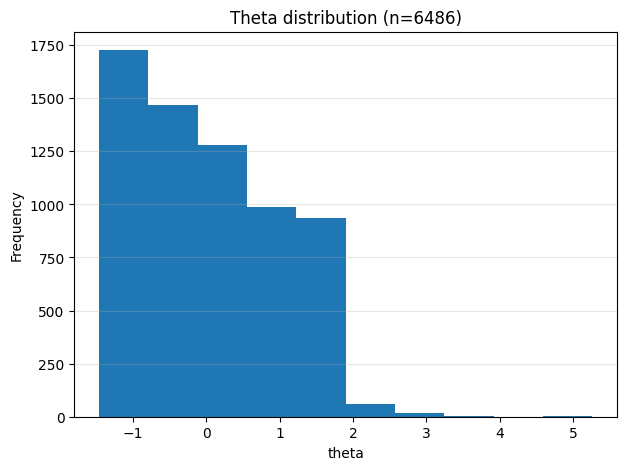

In [74]:
plot_theta_histogram_all(theta_df, bins=10)

In [78]:
from pathlib import Path
import os
import traceback
import pandas as pd
from joblib import Parallel, delayed, parallel_backend


# ============================================================
# 設定
# ============================================================

INPUT_DIR = Path(
    "260829 MMLU data/p_correct_matrices_by_subject"
)

OUTPUT_DIR = Path(
    "260829 MMLU data/IRT_results_by_subject"
)

THETA_DIR = OUTPUT_DIR / "theta"
ITEM_DIR = OUTPUT_DIR / "item"

THETA_DIR.mkdir(parents=True, exist_ok=True)
ITEM_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 並列数
#
# 57 subjectを全部同時に走らせるとメモリをかなり消費するため、
# まずは 4 程度がおすすめ。
# ------------------------------------------------------------
N_JOBS = 4


# ============================================================
# IRT fit の設定
# ここは現在単独subjectで使っている設定に合わせる
# ============================================================

FIT_KWARGS = dict(
    R_b=1,             # binaryを使わない現状では実質影響なし
    outer_iter=100,
    item_maxiter=100,
    tol_obj=1e-6,
    tol_param=1e-4,    # 現在使いたいthresholdに変更
    ridge=1e-4,
    verbose=False,     # 並列時はFalse推奨
    print_every=10,
)


# ============================================================
# 1 subject の分析
# ============================================================

def fit_one_subject(csv_path, overwrite=False):
    """
    1つの MMLU subject CSV を読み込み、
    IRT推定 → theta/item dataframe作成 → CSV保存
    まで行う。

    Parameters
    ----------
    csv_path : str or Path
        MMLU_p_correct_<subject>.csv
    overwrite : bool
        Falseなら既存結果があるsubjectをskip

    Returns
    -------
    dict
        実行結果のsummary
    """

    csv_path = Path(csv_path)

    prefix = "MMLU_p_correct_"

    if not csv_path.stem.startswith(prefix):
        return {
            "subject": csv_path.stem,
            "status": "skipped_invalid_filename",
            "input_file": str(csv_path),
        }

    subject = csv_path.stem.removeprefix(prefix)

    theta_out = THETA_DIR / f"theta_estimates_by_llm_{subject}.csv"
    item_out = ITEM_DIR / f"item_parameter_estimates_{subject}.csv"

    # --------------------------------------------------------
    # 既に両方存在するならskip
    # --------------------------------------------------------
    if (
        not overwrite
        and theta_out.exists()
        and item_out.exists()
    ):
        return {
            "subject": subject,
            "status": "skipped_existing",
            "input_file": str(csv_path),
            "theta_file": str(theta_out),
            "item_file": str(item_out),
        }

    try:
        print(f"[START] {subject}")

        # ====================================================
        # 1. probability data の読み込み・仕分け
        # HELM binary data はまだないので times_path=None
        # ====================================================

        tables = split_llm_observation_tables_safe(
            probabilities_path=csv_path,
            times_path=None,
            name_col="model",
            sort_models=True,
            keep_complete_prob_only_as_full=True,
        )

        p_full = tables["p_full"]
        r_bin = tables["r_bin"]
        p_mix = tables["p_mix"]
        r_mix = tables["r_mix"]
        mask_mix = tables["mask_mix"]

        # ====================================================
        # 2. IRT fit
        # ====================================================

        fit = fit_hybrid_irt_with_itemwise_mixed(
            p_full=p_full,
            r_bin=r_bin,
            p_mix=p_mix,
            r_mix=r_mix,
            mask_mix=mask_mix,
            **FIT_KWARGS,
        )

        # ====================================================
        # 3. DataFrame化
        # ====================================================

        theta_df = make_theta_dataframe(
            fit,
            tables,
        )

        item_df = make_item_parameter_dataframe(
            fit,
            tables=tables,
        )

        # subject列をつけておくと、あとで57分野を結合するとき便利
        theta_df.insert(
            0,
            "subject",
            subject,
        )

        item_df.insert(
            0,
            "subject",
            subject,
        )

        # ====================================================
        # 4. CSV保存
        # ====================================================

        theta_df.to_csv(
            theta_out,
            index=False,
            encoding="utf-8-sig",
        )

        item_df.to_csv(
            item_out,
            index=False,
            encoding="utf-8-sig",
        )

        # ====================================================
        # 5. summary
        # ====================================================

        result = {
            "subject": subject,
            "status": "success",
            "input_file": str(csv_path),

            "n_items": len(item_df),
            "n_theta": len(theta_df),

            "n_full_probability": len(p_full),
            "n_binary": len(r_bin),
            "n_mixed": len(p_mix),

            "converged": fit.get("converged", None),
            "stop_reason": fit.get("stop_reason", None),
            "n_iterations": fit.get("n_iterations", None),
            "final_objective": fit.get(
                "final_objective", None
            ),
            "final_relative_objective_change": fit.get(
                "final_relative_objective_change", None
            ),
            "final_max_parameter_change": fit.get(
                "final_max_parameter_change", None
            ),

            "theta_file": str(theta_out),
            "item_file": str(item_out),
        }

        print(
            f"[DONE]  {subject} | "
            f"converged={result['converged']} | "
            f"iter={result['n_iterations']}"
        )

        return result

    except Exception as e:

        print(
            f"[ERROR] {subject}: "
            f"{type(e).__name__}: {e}"
        )

        return {
            "subject": subject,
            "status": "error",
            "input_file": str(csv_path),
            "error_type": type(e).__name__,
            "error_message": str(e),
            "traceback": traceback.format_exc(),
        }

In [77]:
from pathlib import Path

INPUT_DIR = Path(
    "260829 MMLU data/p_correct_matrices_by_subject"
)

MMLU_SUBJECTS = [
    "abstract_algebra",
    "anatomy",
    "astronomy",
    "business_ethics",
    "clinical_knowledge",
    "college_biology",
    "college_chemistry",
    "college_computer_science",
    "college_mathematics",
    "college_medicine",
    "college_physics",
    "computer_security",
    "conceptual_physics",
    "econometrics",
    "electrical_engineering",
    "elementary_mathematics",
    "formal_logic",
    "global_facts",
    "high_school_biology",
    "high_school_chemistry",
    "high_school_computer_science",
    "high_school_european_history",
    "high_school_geography",
    "high_school_government_and_politics",
    "high_school_macroeconomics",
    "high_school_mathematics",
    "high_school_microeconomics",
    "high_school_physics",
    "high_school_psychology",
    "high_school_statistics",
    "high_school_us_history",
    "high_school_world_history",
    "human_aging",
    "human_sexuality",
    "international_law",
    "jurisprudence",
    "logical_fallacies",
    "machine_learning",
    "management",
    "marketing",
    "medical_genetics",
    "miscellaneous",
    "moral_disputes",
    "moral_scenarios",
    "nutrition",
    "philosophy",
    "prehistory",
    "professional_accounting",
    "professional_law",
    "professional_medicine",
    "professional_psychology",
    "public_relations",
    "security_studies",
    "sociology",
    "us_foreign_policy",
    "virology",
    "world_religions",
]


# ============================================================
# 57 subject のファイルだけ取得
# ============================================================

csv_files = [
    INPUT_DIR / f"MMLU_p_correct_{subject}.csv"
    for subject in MMLU_SUBJECTS
]


# ============================================================
# ファイル存在確認
# ============================================================

missing_files = [
    p for p in csv_files
    if not p.exists()
]

if missing_files:
    print("Missing files:")
    for p in missing_files:
        print("  ", p)
    raise FileNotFoundError(
        f"{len(missing_files)} subject files are missing."
    )


print("Number of MMLU subject files:", len(csv_files))

assert len(csv_files) == 57

for p in csv_files:
    print(p.name)

Number of MMLU subject files: 57
MMLU_p_correct_abstract_algebra.csv
MMLU_p_correct_anatomy.csv
MMLU_p_correct_astronomy.csv
MMLU_p_correct_business_ethics.csv
MMLU_p_correct_clinical_knowledge.csv
MMLU_p_correct_college_biology.csv
MMLU_p_correct_college_chemistry.csv
MMLU_p_correct_college_computer_science.csv
MMLU_p_correct_college_mathematics.csv
MMLU_p_correct_college_medicine.csv
MMLU_p_correct_college_physics.csv
MMLU_p_correct_computer_security.csv
MMLU_p_correct_conceptual_physics.csv
MMLU_p_correct_econometrics.csv
MMLU_p_correct_electrical_engineering.csv
MMLU_p_correct_elementary_mathematics.csv
MMLU_p_correct_formal_logic.csv
MMLU_p_correct_global_facts.csv
MMLU_p_correct_high_school_biology.csv
MMLU_p_correct_high_school_chemistry.csv
MMLU_p_correct_high_school_computer_science.csv
MMLU_p_correct_high_school_european_history.csv
MMLU_p_correct_high_school_geography.csv
MMLU_p_correct_high_school_government_and_politics.csv
MMLU_p_correct_high_school_macroeconomics.csv
MML

In [79]:
# ============================================================
# 並列 IRT
# ============================================================

with parallel_backend(
    "loky",
    inner_max_num_threads=1,
):
    results = Parallel(
        n_jobs=N_JOBS,
        verbose=10,
    )(
        delayed(fit_one_subject)(
            csv_path,
            overwrite=False,
        )
        for csv_path in csv_files
    )


# ============================================================
# 実行summary保存
# ============================================================

summary_df = pd.DataFrame(results)

summary_path = OUTPUT_DIR / "IRT_run_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig",
)

display(summary_df)

print(
    "\nSaved summary:",
    summary_path
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  8.6min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 11.7min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 15.3min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 26.1min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 38.4min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 50.6min
[Parallel(n_jobs=4)]: Done  57 out of  57 | elapsed: 109.0min finished


,subject,status,input_file,n_items,n_theta,n_full_probability,n_binary,n_mixed,converged,stop_reason,n_iterations,final_objective,final_relative_objective_change,final_max_parameter_change,theta_file,item_file
0,abstract_algebra,success,260829 MMLU data\p_correct_matrices_by_subject...,100,6483,6481,0,2,False,max_iter_reached,100,3.574996e+05,3.386526e-09,0.001706,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
1,anatomy,success,260829 MMLU data\p_correct_matrices_by_subject...,135,6483,6481,0,2,True,converged,12,4.000633e+05,8.917504e-07,0.000570,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
2,astronomy,success,260829 MMLU data\p_correct_matrices_by_subject...,152,6483,6480,0,3,False,max_iter_reached,100,4.434540e+05,3.411884e-08,0.095658,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
3,business_ethics,success,260829 MMLU data\p_correct_matrices_by_subject...,100,6486,6480,0,6,False,max_iter_reached,100,3.056641e+05,9.643553e-08,0.166250,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
4,clinical_knowledge,success,260829 MMLU data\p_correct_matrices_by_subject...,265,6483,6480,0,3,False,max_iter_reached,100,7.777038e+05,1.966566e-07,0.097759,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
5,college_biology,success,260829 MMLU data\p_correct_matrices_by_subject...,144,6483,6481,0,2,False,max_iter_reached,100,3.933378e+05,2.527918e-07,0.162258,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
6,college_chemistry,success,260829 MMLU data\p_correct_matrices_by_subject...,100,6482,6480,0,2,True,converged,10,3.280449e+05,3.471565e-07,0.000373,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
7,college_computer_science,success,260829 MMLU data\p_correct_matrices_by_subject...,100,6480,6478,0,2,True,converged,10,3.422646e+05,5.128384e-07,0.000549,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
8,college_mathematics,success,260829 MMLU data\p_correct_matrices_by_subject...,100,6482,6479,0,3,False,max_iter_reached,100,3.669128e+05,1.133367e-08,0.011581,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...
9,college_medicine,success,260829 MMLU data\p_correct_matrices_by_subject...,173,6483,6479,0,4,True,converged,11,5.024660e+05,9.531797e-07,0.000526,260829 MMLU data\IRT_results_by_subject\theta\...,260829 MMLU data\IRT_results_by_subject\item\i...



Saved summary: 260829 MMLU data\IRT_results_by_subject\IRT_run_summary.csv


In [80]:
# ============================================================
# 全subjectのthetaを1つのwide tableにまとめる
# rows    = model
# columns = subject
# ============================================================

theta_long_list = []

for path in sorted(
    THETA_DIR.glob(
        "theta_estimates_by_llm_*.csv"
    )
):
    df = pd.read_csv(
        path,
        encoding="utf-8-sig",
    )

    theta_long_list.append(
        df[
            [
                "subject",
                "LLM_name",
                "theta",
                "theta_se",
            ]
        ].copy()
    )


theta_long = pd.concat(
    theta_long_list,
    ignore_index=True,
)


# theta matrix
theta_wide = theta_long.pivot(
    index="LLM_name",
    columns="subject",
    values="theta",
)

# SE matrix
theta_se_wide = theta_long.pivot(
    index="LLM_name",
    columns="subject",
    values="theta_se",
)


theta_wide.to_csv(
    OUTPUT_DIR / "MMLU_theta_57subjects.csv",
    encoding="utf-8-sig",
)

theta_se_wide.to_csv(
    OUTPUT_DIR / "MMLU_theta_se_57subjects.csv",
    encoding="utf-8-sig",
)


print(
    "theta matrix shape:",
    theta_wide.shape,
)

print(
    "theta SE matrix shape:",
    theta_se_wide.shape,
)

theta matrix shape: (6487, 57)
theta SE matrix shape: (6487, 57)


In [17]:
from pathlib import Path
import os
import traceback
import pandas as pd
from joblib import Parallel, delayed, parallel_backend


# ============================================================
# 設定
# ============================================================

INPUT_DIR1 = Path(
    "260829 MMLU data/p_correct_matrices_by_subject"
)

INPUT_DIR2 = Path(
    "260905 HELM MMLU data/binary_matrices_by_subject"
)
OUTPUT_DIR = Path(
    "260829 MMLU data/mixed_IRT_results_by_subject"
)

THETA_DIR = OUTPUT_DIR / "theta"
ITEM_DIR = OUTPUT_DIR / "item"

THETA_DIR.mkdir(parents=True, exist_ok=True)
ITEM_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 並列数
#
# 57 subjectを全部同時に走らせるとメモリをかなり消費するため、
# まずは 4 程度がおすすめ。
# ------------------------------------------------------------
N_JOBS = 4


# ============================================================
# IRT fit の設定
# ここは現在単独subjectで使っている設定に合わせる
# ============================================================

FIT_KWARGS = dict(
    R_b=1,             # binaryを使わない現状では実質影響なし
    outer_iter=100,
    item_maxiter=100,
    tol_obj=1e-6,
    tol_param=1e-4,    # 現在使いたいthresholdに変更
    ridge=1e-4,
    verbose=False,     # 並列時はFalse推奨
    print_every=10,
)


# ============================================================
# 1 subject の分析
# ============================================================

def fit_mixed_one_subject(csv_path1, csv_path2, overwrite=False):
    """
    1つの subjectを読み込み、
    IRT推定 → theta/item dataframe作成 → CSV保存
    まで行う。

    Parameters
    ----------
    csv_path : str or Path
        MMLU_p_correct_<subject>.csv
    overwrite : bool
        Falseなら既存結果があるsubjectをskip

    Returns
    -------
    dict
        実行結果のsummary
    """

    csv_path1 = Path(csv_path1)
    csv_path2 = Path(csv_path2)

    prefix1 = "MMLU_p_correct_"
    prefix2 = "HELM_MMLU_correct_"

    if not csv_path1.stem.startswith(prefix1):
        return {
            "subject": csv_path1.stem,
            "status": "skipped_invalid_filename",
            "input_file": str(csv_path1),
        }

    if not csv_path2.stem.startswith(prefix2):
        return {
            "subject": csv_path2.stem,
            "status": "skipped_invalid_filename",
            "input_file": str(csv_path2),
        }
    
    subject = csv_path1.stem.removeprefix(prefix1)

    theta_out = THETA_DIR / f"mixed_theta_estimates_by_llm_{subject}.csv"
    item_out = ITEM_DIR / f"mixed_item_parameter_estimates_{subject}.csv"

    # --------------------------------------------------------
    # 既に両方存在するならskip
    # --------------------------------------------------------
    if (
        not overwrite
        and theta_out.exists()
        and item_out.exists()
    ):
        return {
            "subject": subject,
            "status": "skipped_existing",
            "input_file1": str(csv_path1),
            "input_file2": str(csv_path2),
            "theta_file": str(theta_out),
            "item_file": str(item_out),
        }

    try:
        print(f"[START] {subject}")

        # ====================================================
        # 1. data の読み込み・仕分け
        # ====================================================

        tables = split_llm_observation_tables_safe(
            probabilities_path=csv_path1,
            times_path=csv_path2,
            name_col="model",
            sort_models=True,
            keep_complete_prob_only_as_full=True,
        )

        p_full = tables["p_full"]
        r_bin = tables["r_bin"]
        p_mix = tables["p_mix"]
        r_mix = tables["r_mix"]
        mask_mix = tables["mask_mix"]

        # ====================================================
        # 2. IRT fit
        # ====================================================

        fit = fit_hybrid_irt_with_itemwise_mixed(
            p_full=p_full,
            r_bin=r_bin,
            p_mix=p_mix,
            r_mix=r_mix,
            mask_mix=mask_mix,
            **FIT_KWARGS,
        )

        # ====================================================
        # 3. DataFrame化
        # ====================================================

        theta_df = make_theta_dataframe(
            fit,
            tables,
        )

        item_df = make_item_parameter_dataframe(
            fit,
            tables=tables,
        )

        # subject列をつけておくと、あとで57分野を結合するとき便利
        theta_df.insert(
            0,
            "subject",
            subject,
        )

        item_df.insert(
            0,
            "subject",
            subject,
        )

        # ====================================================
        # 4. CSV保存
        # ====================================================

        theta_df.to_csv(
            theta_out,
            index=False,
            encoding="utf-8-sig",
        )

        item_df.to_csv(
            item_out,
            index=False,
            encoding="utf-8-sig",
        )

        # ====================================================
        # 5. summary
        # ====================================================

        result = {
            "subject": subject,
            "status": "success",
            "input_file1": str(csv_path1),
            "input_file2": str(csv_path2),

            "n_items": len(item_df),
            "n_theta": len(theta_df),

            "n_full_probability": len(p_full),
            "n_binary": len(r_bin),
            "n_mixed": len(p_mix),

            "converged": fit.get("converged", None),
            "stop_reason": fit.get("stop_reason", None),
            "n_iterations": fit.get("n_iterations", None),
            "final_objective": fit.get(
                "final_objective", None
            ),
            "final_relative_objective_change": fit.get(
                "final_relative_objective_change", None
            ),
            "final_max_parameter_change": fit.get(
                "final_max_parameter_change", None
            ),

            "theta_file": str(theta_out),
            "item_file": str(item_out),
        }

        print(
            f"[DONE]  {subject} | "
            f"converged={result['converged']} | "
            f"iter={result['n_iterations']}"
        )

        return result

    except Exception as e:

        print(
            f"[ERROR] {subject}: "
            f"{type(e).__name__}: {e}"
        )

        return {
            "subject": subject,
            "status": "error",
            "input_file1": str(csv_path1),
            "input_file2": str(csv_path2),
            "error_type": type(e).__name__,
            "error_message": str(e),
            "traceback": traceback.format_exc(),
        }

In [16]:
from pathlib import Path

INPUT_DIR1 = Path(
    "260829 MMLU data/p_correct_matrices_by_subject"
)

INPUT_DIR2 = Path(
    "260905 HELM MMLU data/binary_matrices_by_subject"
)
    
MMLU_SUBJECTS = [
    "abstract_algebra",
    "anatomy",
    "astronomy",
    "business_ethics",
    "clinical_knowledge",
    "college_biology",
    "college_chemistry",
    "college_computer_science",
    "college_mathematics",
    "college_medicine",
    "college_physics",
    "computer_security",
    "conceptual_physics",
    "econometrics",
    "electrical_engineering",
    "elementary_mathematics",
    "formal_logic",
    "global_facts",
    "high_school_biology",
    "high_school_chemistry",
    "high_school_computer_science",
    "high_school_european_history",
    "high_school_geography",
    "high_school_government_and_politics",
    "high_school_macroeconomics",
    "high_school_mathematics",
    "high_school_microeconomics",
    "high_school_physics",
    "high_school_psychology",
    "high_school_statistics",
    "high_school_us_history",
    "high_school_world_history",
    "human_aging",
    "human_sexuality",
    "international_law",
    "jurisprudence",
    "logical_fallacies",
    "machine_learning",
    "management",
    "marketing",
    "medical_genetics",
    "miscellaneous",
    "moral_disputes",
    "moral_scenarios",
    "nutrition",
    "philosophy",
    "prehistory",
    "professional_accounting",
    "professional_law",
    "professional_medicine",
    "professional_psychology",
    "public_relations",
    "security_studies",
    "sociology",
    "us_foreign_policy",
    "virology",
    "world_religions",
]


# ============================================================
# 57 subject のファイルだけ取得
# ============================================================

csv_files1 = [
    INPUT_DIR1 / f"MMLU_p_correct_{subject}.csv"
    for subject in MMLU_SUBJECTS
]

csv_files2 = [
    INPUT_DIR2 / f"HELM_MMLU_correct_{subject}.csv"
    for subject in MMLU_SUBJECTS
]


# ============================================================
# ファイル存在確認
# ============================================================

missing_files1 = [
    p for p in csv_files1
    if not p.exists()
]

missing_files2 = [
    p for p in csv_files2
    if not p.exists()
]

if missing_files1:
    print("Missing files:")
    for p in missing_files1:
        print("  ", p)
    raise FileNotFoundError(
        f"{len(missing_files1)} subject files are missing."
    )

if missing_files2:
    print("Missing files:")
    for p in missing_files2:
        print("  ", p)
    raise FileNotFoundError(
        f"{len(missing_files2)} subject files are missing."
    )


print("Number of MMLU subject files:", len(csv_files1))
print("Number of HELM subject files:", len(csv_files2))

assert len(csv_files1) == 57

for p in csv_files1:
    print(p.name)

for p in csv_files2:
    print(p.name)

Number of MMLU subject files: 57
Number of HELM subject files: 57
MMLU_p_correct_abstract_algebra.csv
MMLU_p_correct_anatomy.csv
MMLU_p_correct_astronomy.csv
MMLU_p_correct_business_ethics.csv
MMLU_p_correct_clinical_knowledge.csv
MMLU_p_correct_college_biology.csv
MMLU_p_correct_college_chemistry.csv
MMLU_p_correct_college_computer_science.csv
MMLU_p_correct_college_mathematics.csv
MMLU_p_correct_college_medicine.csv
MMLU_p_correct_college_physics.csv
MMLU_p_correct_computer_security.csv
MMLU_p_correct_conceptual_physics.csv
MMLU_p_correct_econometrics.csv
MMLU_p_correct_electrical_engineering.csv
MMLU_p_correct_elementary_mathematics.csv
MMLU_p_correct_formal_logic.csv
MMLU_p_correct_global_facts.csv
MMLU_p_correct_high_school_biology.csv
MMLU_p_correct_high_school_chemistry.csv
MMLU_p_correct_high_school_computer_science.csv
MMLU_p_correct_high_school_european_history.csv
MMLU_p_correct_high_school_geography.csv
MMLU_p_correct_high_school_government_and_politics.csv
MMLU_p_correct_h

In [20]:
# ============================================================
# 並列 IRT
# ============================================================

with parallel_backend(
    "loky",
    inner_max_num_threads=1,
):
    results = Parallel(
        n_jobs=N_JOBS,
        verbose=10,
    )(
        delayed(fit_mixed_one_subject)(
            csv_path1,
            csv_path2,
            overwrite=False,
        )
        for csv_path1, csv_path2 in zip(csv_files1, csv_files2)
    )


# ============================================================
# 実行summary保存
# ============================================================

summary_df = pd.DataFrame(results)

summary_path = OUTPUT_DIR / "mixed_IRT_run_summary.csv"

summary_df.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig",
)

display(summary_df)

print(
    "\nSaved summary:",
    summary_path
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:  7.8min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 10.4min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 19.9min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 31.3min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 44.1min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 60.2min
[Parallel(n_jobs=4)]: Done  57 out of  57 | elapsed: 103.9min finished


,subject,status,input_file1,input_file2,n_items,n_theta,n_full_probability,n_binary,n_mixed,converged,stop_reason,n_iterations,final_objective,final_relative_objective_change,final_max_parameter_change,theta_file,item_file
0,abstract_algebra,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,100,6540,6459,57,24,False,max_iter_reached,100,3.618880e+05,6.660234e-09,0.004939,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
1,anatomy,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,135,6540,6459,57,24,True,converged,14,4.037506e+05,2.487561e-07,0.000173,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
2,astronomy,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,152,6540,6458,57,25,False,max_iter_reached,100,4.471268e+05,1.979514e-07,0.155734,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
3,business_ethics,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,100,6543,6458,57,28,True,converged,18,3.086830e+05,1.327390e-07,0.001016,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
4,clinical_knowledge,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,265,6540,6458,57,25,False,max_iter_reached,100,7.848298e+05,1.938100e-08,0.125914,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
5,college_biology,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,144,6540,6459,57,24,False,max_iter_reached,100,3.966764e+05,1.045698e-07,0.077295,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
6,college_chemistry,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,100,6539,6458,57,24,True,converged,10,3.314401e+05,3.605220e-07,0.000402,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
7,college_computer_science,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,100,6537,6456,57,24,True,converged,11,3.459119e+05,2.670888e-07,0.000303,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
8,college_mathematics,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,100,6539,6457,57,25,True,converged,11,3.716778e+05,1.362647e-07,0.000920,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...
9,college_medicine,success,260829 MMLU data\p_correct_matrices_by_subject...,260905 HELM MMLU data\binary_matrices_by_subje...,173,6540,6457,57,26,True,converged,11,5.074092e+05,9.917130e-07,0.000592,260829 MMLU data\mixed_IRT_results_by_subject\...,260829 MMLU data\mixed_IRT_results_by_subject\...



Saved summary: 260829 MMLU data\mixed_IRT_results_by_subject\mixed_IRT_run_summary.csv


In [21]:
# ============================================================
# 全subjectのthetaを1つのwide tableにまとめる
# rows    = model
# columns = subject
# ============================================================

theta_long_list = []

for path in sorted(
    THETA_DIR.glob(
        "mixed_theta_estimates_by_llm_*.csv"
    )
):
    df = pd.read_csv(
        path,
        encoding="utf-8-sig",
    )

    theta_long_list.append(
        df[
            [
                "subject",
                "LLM_name",
                "theta",
                "theta_se",
            ]
        ].copy()
    )


theta_long = pd.concat(
    theta_long_list,
    ignore_index=True,
)


# theta matrix
theta_wide = theta_long.pivot(
    index="LLM_name",
    columns="subject",
    values="theta",
)

# SE matrix
theta_se_wide = theta_long.pivot(
    index="LLM_name",
    columns="subject",
    values="theta_se",
)


theta_wide.to_csv(
    OUTPUT_DIR / "mixed_MMLU_theta_57subjects.csv",
    encoding="utf-8-sig",
)

theta_se_wide.to_csv(
    OUTPUT_DIR / "mixed_MMLU_theta_se_57subjects.csv",
    encoding="utf-8-sig",
)


print(
    "theta matrix shape:",
    theta_wide.shape,
)

print(
    "theta SE matrix shape:",
    theta_se_wide.shape,
)

theta matrix shape: (6544, 57)
theta SE matrix shape: (6544, 57)


シミュレーション

In [ ]:
import numpy as np
import pandas as pd
from dataclasses import dataclass

D = 1.702


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -40.0, 40.0)))


@dataclass
class MixedSimulationData:
    p_full_df: pd.DataFrame
    r_bin_df: pd.DataFrame
    p_mix_df: pd.DataFrame
    r_mix_df: pd.DataFrame
    mask_mix_df: pd.DataFrame

    # true parameters for simulation diagnostics
    a_true: np.ndarray
    b_true: np.ndarray
    theta_full_true: np.ndarray
    theta_bin_true: np.ndarray
    theta_mix_true: np.ndarray

    # underlying IRT probabilities
    mu_full: np.ndarray
    mu_bin: np.ndarray
    mu_mix: np.ndarray

    R_b: int
    binary_fraction: float


def simulate_itemwise_mixed_dataframes(
    n_full_probability=100,
    n_full_binary=100,
    n_mixed=100,
    n_items=100,
    R_b=5,
    binary_fraction=0.3,
    seed=42,
    item_b_low=-2.0,
    item_b_high=2.0,
    a_low=0.5,
    a_high=2.0,
):
    """
    Generate simulation DataFrames for the new hybrid IRT.

    Probability channel:
      q is deterministic. Under the correctly specified simulation,
      q is set exactly equal to the IRT probability mu.

    Binary channel:
      r ~ Binomial(R_b, mu).

    Mixed group:
      mask==1 marks cells with probability observations.
      Binary counts are also generated for all cells, so mask==1 cells
      contribute both channels if r_mix is left finite.
    """
    if not (0.0 <= binary_fraction <= 1.0):
        raise ValueError("binary_fraction must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    # Item parameters
    a_true = rng.uniform(a_low, a_high, n_items)
    b_true = rng.uniform(item_b_low, item_b_high, n_items)

    # Ability parameters
    theta_full_true = rng.normal(0.0, 1.0, n_full_probability)
    theta_bin_true = rng.normal(0.0, 1.0, n_full_binary)
    theta_mix_true = rng.normal(0.0, 1.0, n_mixed)

    item_names = [f"item_{j+1:03d}" for j in range(n_items)]
    full_names = [f"prob_llm_{g+1:03d}" for g in range(n_full_probability)]
    bin_names = [f"bin_llm_{g+1:03d}" for g in range(n_full_binary)]
    mix_names = [f"mix_llm_{g+1:03d}" for g in range(n_mixed)]

    def generate_deterministic_probabilities(theta):
        eta = D * a_true[None, :] * (theta[:, None] - b_true[None, :])
        mu = sigmoid(eta)
        q = mu.copy()
        return q, mu

    def generate_binary_counts(theta):
        eta = D * a_true[None, :] * (theta[:, None] - b_true[None, :])
        mu = sigmoid(eta)
        r = rng.binomial(R_b, mu)
        return r, mu

    # full probability group
    p_full, mu_full = generate_deterministic_probabilities(theta_full_true)

    # full binary group
    r_bin, mu_bin = generate_binary_counts(theta_bin_true)

    # mixed group
    p_mix, mu_mix = generate_deterministic_probabilities(theta_mix_true)
    r_mix, _ = generate_binary_counts(theta_mix_true)

    # 1 = probability observation is available, 0 = unavailable
    mask_mix = (
        rng.random(size=(n_mixed, n_items)) >= binary_fraction
    ).astype(int)

    # Probability unavailable cells are NaN.
    # Binary remains available in this simulation.
    p_mix_obs = p_mix.copy()
    p_mix_obs[mask_mix == 0] = np.nan

    # Convert to DataFrames
    p_full_df = pd.DataFrame(
        p_full, index=full_names, columns=item_names
    )
    r_bin_df = pd.DataFrame(
        r_bin, index=bin_names, columns=item_names
    )
    p_mix_df = pd.DataFrame(
        p_mix_obs, index=mix_names, columns=item_names
    )
    r_mix_df = pd.DataFrame(
        r_mix, index=mix_names, columns=item_names
    )
    mask_mix_df = pd.DataFrame(
        mask_mix, index=mix_names, columns=item_names
    )

    return MixedSimulationData(
        p_full_df=p_full_df,
        r_bin_df=r_bin_df,
        p_mix_df=p_mix_df,
        r_mix_df=r_mix_df,
        mask_mix_df=mask_mix_df,
        a_true=a_true,
        b_true=b_true,
        theta_full_true=theta_full_true,
        theta_bin_true=theta_bin_true,
        theta_mix_true=theta_mix_true,
        mu_full=mu_full,
        mu_bin=mu_bin,
        mu_mix=mu_mix,
        R_b=R_b,
        binary_fraction=binary_fraction,
    )


In [ ]:
sim = simulate_itemwise_mixed_dataframes(
    n_full_probability=4,
    n_full_binary=26,
    n_mixed=43,
    n_items=110,
    R_b=5,
    binary_fraction=0.33,
    seed=25,
)

p_full_df = sim.p_full_df
r_bin_df = sim.r_bin_df

p_mix_df = sim.p_mix_df
r_mix_df = sim.r_mix_df
mask_mix_df = sim.mask_mix_df


In [ ]:
fit_sim = fit_hybrid_irt_with_itemwise_mixed(
    p_full=p_full_df,
    r_bin=r_bin_df,
    p_mix=p_mix_df,
    r_mix=r_mix_df,
    mask_mix=mask_mix_df,
    R_b=sim.R_b,
    outer_iter=1000,
    item_maxiter=1000,
    verbose=True,
)


In [ ]:
fit_sim

In [ ]:
def summarize_result(fit, sim):
    a_t,b_t,tf_t,tb_t,tm_t=align_true_mixed(sim)
    return {
        "binary_fraction_target": sim.binary_fraction,
        "binary_fraction_actual": float((sim.mask_mix_df.to_numpy()==0).mean()),
        "rmse_a": rmse(fit["a"], a_t),
        "rmse_b": rmse(fit["b"], b_t),
        "corr_a": corr(fit["a"], a_t),
        "corr_b": corr(fit["b"], b_t),
        "mean_a_se": float(np.sqrt(np.mean(fit["a_se"]**2))),
        "median_a_se": float(np.median(fit["a_se"])),
        "p90_a_se": float(np.quantile(fit["a_se"], .90)),
        "mean_b_se": float(np.sqrt(np.mean(fit["b_se"]**2))),
        "median_b_se": float(np.median(fit["b_se"])),
        "p90_b_se": float(np.quantile(fit["b_se"], .90)),
        "rmse_theta_full_probability": rmse(fit["theta_full_probability"], tf_t),
        "rmse_theta_binary": rmse(fit["theta_binary"], tb_t),
        "rmse_theta_mixed": rmse(fit["theta_mixed"], tm_t),
        "mean_theta_full_probability_se": float(np.sqrt(np.mean(fit["theta_full_probability_se"]**2))),
        "mean_theta_binary_se": float(np.sqrt(np.mean(fit["theta_binary_se"]**2))),
        "mean_theta_mixed_se": float(np.sqrt(np.mean(fit["theta_mixed_se"]**2))),
        "converged": fit["converged"],
        "n_iterations": fit["n_iterations"],
        "final_rel_obj_change": fit["final_relative_objective_change"],
        "final_max_param_change": fit["final_max_parameter_change"],
    }

def align_true_mixed(sim):
    return standardize_params_mixed(
        sim.a_true.copy(), sim.b_true.copy(),
        sim.theta_full_true.copy(), sim.theta_bin_true.copy(), sim.theta_mix_true.copy()
    )

In [ ]:
rows=[]
rows.append(summarize_result(fit_sim, sim))
sim_df=pd.DataFrame(rows)
display_cols = ["binary_fraction_target","binary_fraction_actual","rmse_a","rmse_b","mean_a_se","mean_b_se",
                "rmse_theta_mixed","mean_theta_mixed_se","mean_theta_full_probability_se","mean_theta_binary_se","converged","n_iterations",
                "final_rel_obj_change","final_max_param_change"]
sim_df[display_cols]